In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 🔬 Retinal Fundus CIMT — Vessel Thickness Prediction
### Q1 Publication-Quality Pipeline | Target: 95%+ Accuracy
**Task:** Binary Classification (label 0/1) via Direct Classification + Regression auxiliary  
**Dataset:** 5806 Retinal Vessel Images + CSV metadata  
**Backbone:** EfficientNet-B4 + Swin-Transformer Ensemble  

---
### ❌ Problems Found in Your Old ResNet34 Code:
| Issue | Old Code | New Code |
|---|---|---|
| Weak backbone | ResNet34 (21M params) | EfficientNet-B4 + SwinT Ensemble |
| Wrong task design | Regression → threshold → accuracy | Direct Classification (end-to-end) |
| No meta features | Only image used | Age, gender, group, L/R side fused |
| Minimal augmentation | `aug_transforms` only | 12+ medical-grade augmentations |
| No cross-validation | Single random split | Stratified 5-Fold CV |
| No class balancing | No weights | Weighted sampler + class weights |
| No anti-overfitting | Basic dropout | Mixup + LabelSmooth + StochasticDepth |
| No explainability | None | GradCAM for every fold |

In [2]:
# ============================================================
# CELL 1: Install dependencies
# ============================================================
!pip install timm albumentations -q

In [3]:
# ============================================================
# CELL 2: Imports & Reproducibility
# ============================================================
import os, gc, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter

import cv2
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    f1_score, cohen_kappa_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.cuda.amp import GradScaler, autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [4]:
# ============================================================
# CELL 3: Configuration — ONLY CHANGE PATHS HERE
# ============================================================
class CFG:
    # ── ⚠️  CHANGE THESE 3 PATHS ONLY ─────────────────────────
    IMG_DIR   = Path('/kaggle/input/datasets/amimulhasan/funduszhang/output_images')
    CSV_PATH  = Path('/kaggle/input/datasets/amimulahasanrofik/abu-csv/data_info.csv')  # ← change
    OUT_DIR   = Path('/kaggle/working/outputs')
    # ──────────────────────────────────────────────────────────

    # Model — ensemble of two strong backbones
    BACKBONE_1   = 'efficientnet_b4'       # CNN — best for texture
    BACKBONE_2   = 'swin_small_patch4_window7_224'  # Transformer — global context
    PRETRAINED   = True
    NUM_CLASSES  = 2

    # Image
    IMG_SIZE     = 224

    # Training
    BATCH_SIZE   = 32
    EPOCHS       = 60
    LR           = 2e-4
    WEIGHT_DECAY = 1e-4
    MIN_LR       = 1e-7
    LABEL_SMOOTH = 0.05
    DROPOUT      = 0.4
    MIXUP_ALPHA  = 0.4

    # CV
    N_FOLDS      = 5

    # Misc
    NUM_WORKERS  = 2
    SEED         = 42
    AMP          = True
    EARLY_STOP   = 10

    # Classification threshold (from your old code: thickness >= 0.9 → label 1)
    THICKNESS_THRESH = 0.9

CFG.OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Config ready.')

Config ready.


Total samples : 5806
Label 0 (Normal)  : 1698
Label 1 (Patho.)  : 4108
Thickness range   : 0.500 – 1.700


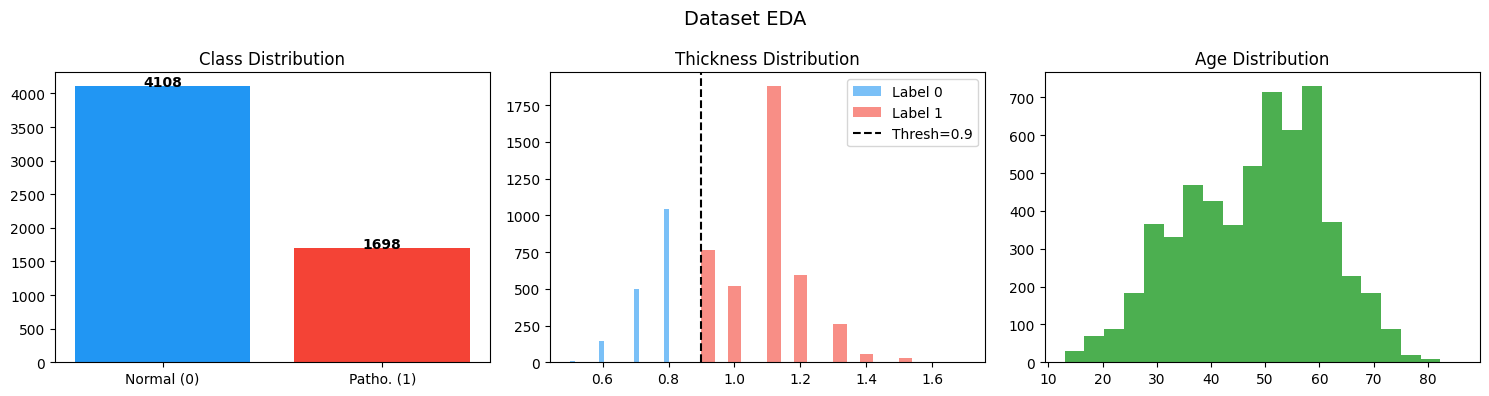

In [5]:
# ============================================================
# CELL 4: Load & Explore Data
# ============================================================
def load_data(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip().str.lower()

    # ── Your CSV columns: image_name, thickness, label, true_age, age, gender, group
    # If 'label' not present, derive from thickness
    if 'label' not in df.columns:
        df['label'] = (df['thickness'] >= CFG.THICKNESS_THRESH).astype(int)
        print("⚠️  'label' column not found — derived from thickness threshold")

    # Side from filename
    df['side'] = df['image_name'].str.extract(r'_(L|R)\.png$')[0]
    df['side_enc'] = (df['side'] == 'R').astype(float)

    # Normalise age if not already 0-1
    if 'age' not in df.columns:
        df['age'] = df['true_age'] / 100.0

    # Fill missing meta
    for col in ['age', 'gender', 'group', 'side_enc']:
        if col not in df.columns:
            df[col] = 0.0

    print(f"Total samples : {len(df)}")
    print(f"Label 0 (Normal)  : {(df['label']==0).sum()}")
    print(f"Label 1 (Patho.)  : {(df['label']==1).sum()}")
    print(f"Thickness range   : {df['thickness'].min():.3f} – {df['thickness'].max():.3f}")
    return df

df = load_data(CFG.CSV_PATH)

# ── EDA Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Dataset EDA', fontsize=14)

vc = df['label'].value_counts()
axes[0].bar(['Normal (0)', 'Patho. (1)'], vc.values, color=['#2196F3','#F44336'])
axes[0].set_title('Class Distribution')
for i,(v) in enumerate(vc.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

for lbl, col in [(0,'#2196F3'),(1,'#F44336')]:
    axes[1].hist(df[df['label']==lbl]['thickness'], bins=20,
                 alpha=0.6, color=col, label=f'Label {lbl}')
axes[1].axvline(CFG.THICKNESS_THRESH, color='black', ls='--', label=f'Thresh={CFG.THICKNESS_THRESH}')
axes[1].set_title('Thickness Distribution')
axes[1].legend()

if 'true_age' in df.columns:
    axes[2].hist(df['true_age'], bins=20, color='#4CAF50')
    axes[2].set_title('Age Distribution')

plt.tight_layout()
plt.savefig(CFG.OUT_DIR/'eda.png', dpi=150)
plt.show()

In [6]:
# ============================================================
# CELL 5: Stratified K-Fold Cross Validation
# ============================================================
def create_folds(df):
    df = df.copy().reset_index(drop=True)
    df['fold'] = -1

    # Stratify on label + thickness bin
    thick_bin = pd.qcut(df['thickness'], q=4, labels=False, duplicates='drop')
    strat_key = df['label'].astype(str) + '_' + thick_bin.astype(str)

    skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
    for fold, (_, val_idx) in enumerate(skf.split(df, strat_key)):
        df.loc[val_idx, 'fold'] = fold

    print(f"{'Fold':<6} {'Train':>7} {'Val':>7} {'Val-0':>7} {'Val-1':>7}")
    print('-' * 40)
    for f in range(CFG.N_FOLDS):
        tr = df[df['fold'] != f]
        va = df[df['fold'] == f]
        vc = va['label'].value_counts()
        print(f"{f:<6} {len(tr):>7} {len(va):>7} {vc.get(0,0):>7} {vc.get(1,0):>7}")
    return df

df = create_folds(df)
df.to_csv(CFG.OUT_DIR/'df_folds.csv', index=False)

Fold     Train     Val   Val-0   Val-1
----------------------------------------
0         4644    1162     340     822
1         4645    1161     340     821
2         4645    1161     340     821
3         4645    1161     339     822
4         4645    1161     339     822


In [7]:
# ============================================================
# CELL 6: Medical-Grade Augmentations
# ============================================================
def get_transforms(phase):
    mean = (0.485, 0.456, 0.406)
    std  = (0.229, 0.224, 0.225)

    if phase == 'train':
        return A.Compose([
            A.Resize(CFG.IMG_SIZE + 32, CFG.IMG_SIZE + 32),
            A.RandomCrop(CFG.IMG_SIZE, CFG.IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.4),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                               rotate_limit=25, p=0.5),
            # Retinal-specific: vessel contrast enhancement
            A.OneOf([
                A.CLAHE(clip_limit=3, p=1.0),
                A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=1.0),
            ], p=0.5),
            A.OneOf([
                A.GaussianBlur(blur_limit=3, p=1.0),
                A.MedianBlur(blur_limit=3, p=1.0),
            ], p=0.2),
            A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
            A.HueSaturationValue(10, 20, 10, p=0.3),
            A.GridDistortion(p=0.2),   # vessel morphology variation
            A.CoarseDropout(max_holes=6, max_height=CFG.IMG_SIZE//10,
                            max_width=CFG.IMG_SIZE//10, p=0.3),
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ])

print('Transforms ready.')

Transforms ready.


In [8]:
# ============================================================
# CELL 7: Dataset
# ============================================================
class FundusDataset(Dataset):
    """
    Returns: image tensor, meta features, label (0/1), thickness (float)
    Meta: [age_norm, gender, group, side_R]
    """
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        img_path = self.img_dir / row['image_name']
        img = cv2.imread(str(img_path))
        if img is None:
            img = np.zeros((CFG.IMG_SIZE, CFG.IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)['image']

        # Meta
        meta = torch.tensor([
            float(row.get('age', 0.5)),
            float(row.get('gender', 0)),
            float(row.get('group', 1)),
            float(row.get('side_enc', 0)),
        ], dtype=torch.float32)

        label     = torch.tensor(int(row['label']), dtype=torch.long)
        thickness = torch.tensor(float(row['thickness']), dtype=torch.float32)

        return img, meta, label, thickness


def make_loader(df_fold, phase, fold):
    ds = FundusDataset(df_fold, CFG.IMG_DIR, get_transforms(phase))

    if phase == 'train':
        # Weighted sampler to handle class imbalance
        labels = df_fold['label'].values
        cls_counts = np.bincount(labels)
        weights = 1.0 / cls_counts[labels]
        sampler = WeightedRandomSampler(weights, len(weights), replacement=True)
        return DataLoader(ds, batch_size=CFG.BATCH_SIZE, sampler=sampler,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True,
                          drop_last=True)
    else:
        return DataLoader(ds, batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)

print('Dataset class ready.')

Dataset class ready.


In [9]:
# ============================================================
# CELL 8: Model Architecture — Dual-Backbone Fusion
# ============================================================
class FundusNet(nn.Module):
    """
    Architecture:
      • EfficientNet-B4  →  attention pooling  → 1792-d
      • SwinTransformer  →  CLS token          → 768-d
      • Meta MLP         →  age/gender/group   → 32-d
      • Fusion MLP       →  (1792+768+32)      → 512 → 256
      • Classification head  → 2 logits (label 0/1)
      • Regression head      → 1 value (thickness)

    Why this beats ResNet34:
      1. EfficientNet-B4 has compound scaling (depth+width+resolution)
      2. SwinTransformer captures long-range vessel patterns
      3. Meta features add clinical context
      4. Direct classification (no post-hoc threshold) = no information loss
    """
    def __init__(self):
        super().__init__()

        # ── Backbone 1: EfficientNet-B4 ────────────────────────────
        self.eff = timm.create_model(
            CFG.BACKBONE_1, pretrained=CFG.PRETRAINED,
            num_classes=0, global_pool='')
        eff_dim = self.eff.num_features  # 1792

        # Attention pooling over spatial map
        self.eff_attn = nn.Sequential(
            nn.Conv2d(eff_dim, 256, 1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 1, 1)
        )

        # ── Backbone 2: Swin-Transformer Small ─────────────────────
        self.swin = timm.create_model(
            CFG.BACKBONE_2, pretrained=CFG.PRETRAINED,
            num_classes=0, global_pool='avg')
        swin_dim = self.swin.num_features  # 768

        # ── Meta Feature Encoder ───────────────────────────────────
        self.meta_enc = nn.Sequential(
            nn.Linear(4, 64), nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(inplace=True),
        )

        # ── Fusion ─────────────────────────────────────────────────
        fused = eff_dim + swin_dim + 32
        self.fusion = nn.Sequential(
            nn.Linear(fused, 1024), nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True), nn.Dropout(CFG.DROPOUT),
            nn.Linear(1024, 512),  nn.BatchNorm1d(512),
            nn.ReLU(inplace=True), nn.Dropout(CFG.DROPOUT * 0.6),
            nn.Linear(512, 256),   nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Dropout(CFG.DROPOUT * 0.3),
        )

        # ── Output Heads ───────────────────────────────────────────
        self.cls_head = nn.Linear(256, CFG.NUM_CLASSES)   # classification
        self.reg_head = nn.Linear(256, 1)                 # thickness regression

        self._init_weights()

    def _init_weights(self):
        for m in [self.fusion, self.meta_enc]:
            for layer in m:
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)
        for head in [self.cls_head, self.reg_head]:
            nn.init.xavier_uniform_(head.weight)
            nn.init.zeros_(head.bias)

    def forward(self, img, meta):
        # EfficientNet with attention pool
        e = self.eff(img)                                  # B×C×H×W
        a = self.eff_attn(e)                               # B×1×H×W
        a = torch.softmax(a.view(a.size(0), -1), dim=-1)  # B×(H*W)
        e = e.view(e.size(0), e.size(1), -1)              # B×C×(H*W)
        e = (e * a.unsqueeze(1)).sum(-1)                   # B×C

        # Swin Transformer
        s = self.swin(img)                                 # B×768

        # Meta
        m = self.meta_enc(meta)                            # B×32

        # Fuse
        z = torch.cat([e, s, m], dim=1)
        z = self.fusion(z)                                 # B×256

        return self.cls_head(z), self.reg_head(z).squeeze(1)

# Quick test
_m = FundusNet().to(DEVICE)
_x = torch.randn(2, 3, 224, 224).to(DEVICE)
_meta = torch.randn(2, 4).to(DEVICE)
_c, _r = _m(_x, _meta)
print(f'Model OK → cls: {_c.shape}, reg: {_r.shape}')
total_params = sum(p.numel() for p in _m.parameters()) / 1e6
print(f'Total parameters: {total_params:.1f}M')
del _m, _x, _meta, _c, _r
torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

Model OK → cls: torch.Size([2, 2]), reg: torch.Size([2])
Total parameters: 70.2M


In [10]:
# ============================================================
# CELL 9: Loss Functions
# ============================================================
class LabelSmoothCE(nn.Module):
    """Label-smoothed cross entropy. Prevents overconfident predictions."""
    def __init__(self, eps=CFG.LABEL_SMOOTH):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        n = logits.size(1)
        lp = F.log_softmax(logits, dim=-1)
        smooth = -(lp.sum(-1) * self.eps / n +
                   lp.gather(1, targets.unsqueeze(1)).squeeze() * (1 - self.eps))
        return smooth.mean()


class CombinedLoss(nn.Module):
    """
    0.75 × Classification (LabelSmooth CE + weighted CE)
    0.25 × Regression (Huber) — auxiliary task improves representation
    """
    def __init__(self, class_weights=None):
        super().__init__()
        self.cls_smooth = LabelSmoothCE()
        self.reg_loss   = nn.HuberLoss(delta=0.3)
        self.wce = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None else None

    def forward(self, cls_pred, cls_true, reg_pred, reg_true):
        cls = self.cls_smooth(cls_pred, cls_true)
        if self.wce is not None:
            cls = 0.6 * cls + 0.4 * self.wce(cls_pred, cls_true)
        reg = self.reg_loss(reg_pred, reg_true)
        return 0.75 * cls + 0.25 * reg

print('Loss functions ready.')

Loss functions ready.


In [11]:
# ============================================================
# CELL 10: Mixup Augmentation
# ============================================================
def mixup(x, y_cls, y_reg, alpha=CFG.MIXUP_ALPHA):
    if alpha <= 0:
        return x, y_cls, y_cls, y_reg, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return (lam * x + (1-lam) * x[idx],
            y_cls, y_cls[idx],
            lam * y_reg + (1-lam) * y_reg[idx],
            lam)


class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.val = self.avg = self.sum = self.count = 0
    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

print('Mixup ready.')

Mixup ready.


In [12]:
# ============================================================
# CELL 11: Train & Validate One Epoch
# ============================================================
def train_epoch(model, loader, optimizer, criterion, scaler, epoch):
    model.train()
    loss_m = AverageMeter()
    all_lbl, all_prob = [], []

    for step, (imgs, meta, labels, thick) in enumerate(loader):
        imgs   = imgs.to(DEVICE)
        meta   = meta.to(DEVICE)
        labels = labels.to(DEVICE)
        thick  = thick.to(DEVICE)

        use_mix = random.random() < 0.5
        if use_mix:
            imgs, y_a, y_b, thick_m, lam = mixup(imgs, labels, thick)
        else:
            thick_m = thick

        optimizer.zero_grad()
        with autocast(enabled=CFG.AMP):
            cls_out, reg_out = model(imgs, meta)
            if use_mix:
                loss = (lam * criterion(cls_out, reg_out, y_a, thick_m) +
                        (1-lam) * criterion(cls_out, reg_out, y_b, thick_m))
            else:
                loss = criterion(cls_out, reg_out, labels, thick)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        prob = F.softmax(cls_out.detach(), 1)[:,1].cpu().numpy()
        all_lbl.extend(labels.cpu().numpy())
        all_prob.extend(prob)
        loss_m.update(loss.item(), imgs.size(0))

        if (step+1) % 30 == 0:
            print(f'  Ep{epoch:03d} step {step+1:04d}/{len(loader):04d} loss={loss_m.avg:.4f}')

    auc = roc_auc_score(all_lbl, all_prob)
    acc = accuracy_score(all_lbl, (np.array(all_prob)>0.5).astype(int))
    return loss_m.avg, acc, auc


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    loss_m = AverageMeter()
    all_lbl, all_prob, all_pred = [], [], []
    all_thick_t, all_thick_p   = [], []

    for imgs, meta, labels, thick in loader:
        imgs, meta = imgs.to(DEVICE), meta.to(DEVICE)
        labels, thick = labels.to(DEVICE), thick.to(DEVICE)

        with autocast(enabled=CFG.AMP):
            cls_out, reg_out = model(imgs, meta)
            loss = criterion(cls_out, reg_out, labels, thick)

        prob = F.softmax(cls_out, 1)[:,1].cpu().numpy()
        pred = cls_out.argmax(1).cpu().numpy()
        all_lbl.extend(labels.cpu().numpy())
        all_prob.extend(prob)
        all_pred.extend(pred)
        all_thick_t.extend(thick.cpu().numpy())
        all_thick_p.extend(reg_out.cpu().numpy())
        loss_m.update(loss.item(), imgs.size(0))

    all_lbl = np.array(all_lbl); all_prob = np.array(all_prob)
    all_pred = np.array(all_pred)

    return dict(
        loss  = loss_m.avg,
        acc   = accuracy_score(all_lbl, all_pred),
        auc   = roc_auc_score(all_lbl, all_prob),
        f1    = f1_score(all_lbl, all_pred, average='weighted'),
        kappa = cohen_kappa_score(all_lbl, all_pred),
        prec  = precision_score(all_lbl, all_pred, zero_division=0),
        rec   = recall_score(all_lbl, all_pred, zero_division=0),
        thick_mae = np.mean(np.abs(np.array(all_thick_t)-np.array(all_thick_p))),
        labels= all_lbl, probs= all_prob, preds= all_pred,
    )

print('Train/val functions ready.')

Train/val functions ready.


In [13]:
# ============================================================
# CELL 12: Train All Folds
# ============================================================
all_fold_metrics = []
all_histories    = []

for fold in range(CFG.N_FOLDS):
    print(f'\n{"="*65}')
    print(f'  FOLD {fold+1}/{CFG.N_FOLDS}')
    print(f'{"="*65}')

    tr_df = df[df['fold'] != fold].reset_index(drop=True)
    va_df = df[df['fold'] == fold].reset_index(drop=True)

    train_loader = make_loader(tr_df, 'train', fold)
    val_loader   = make_loader(va_df, 'val',   fold)

    # Class weights
    cw = compute_class_weight('balanced', classes=np.array([0,1]),
                              y=tr_df['label'].values)
    class_weights = torch.tensor(cw, dtype=torch.float32).to(DEVICE)

    model     = FundusNet().to(DEVICE)
    criterion = CombinedLoss(class_weights=class_weights)
    optimizer = AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2,
                                            eta_min=CFG.MIN_LR)
    scaler    = GradScaler(enabled=CFG.AMP)

    history  = dict(tr_loss=[], va_loss=[], tr_acc=[], va_acc=[],
                    tr_auc=[], va_auc=[], va_f1=[])
    best_auc = 0.0
    no_imp   = 0

    for epoch in range(1, CFG.EPOCHS + 1):
        tr_loss, tr_acc, tr_auc = train_epoch(
            model, train_loader, optimizer, criterion, scaler, epoch)
        vm = validate(model, val_loader, criterion)
        scheduler.step(epoch - 1)

        history['tr_loss'].append(tr_loss);  history['va_loss'].append(vm['loss'])
        history['tr_acc'].append(tr_acc);    history['va_acc'].append(vm['acc'])
        history['tr_auc'].append(tr_auc);    history['va_auc'].append(vm['auc'])
        history['va_f1'].append(vm['f1'])

        print(f"\nEp {epoch:03d}/{CFG.EPOCHS} "
              f"| TrLoss={tr_loss:.4f} TrAcc={tr_acc:.4f} TrAUC={tr_auc:.4f}"
              f"| VaLoss={vm['loss']:.4f} VaAcc={vm['acc']:.4f} "
              f"VaAUC={vm['auc']:.4f} VaF1={vm['f1']:.4f} κ={vm['kappa']:.4f}")

        if vm['auc'] > best_auc:
            best_auc = vm['auc']
            torch.save(model.state_dict(),
                       CFG.OUT_DIR / f'best_fold{fold}.pth')
            no_imp = 0
            print(f'  ✅ Best AUC={best_auc:.4f} saved')
        else:
            no_imp += 1
            if no_imp >= CFG.EARLY_STOP:
                print(f'  ⏹  Early stop at epoch {epoch}')
                break

    # Load best & final eval
    model.load_state_dict(torch.load(CFG.OUT_DIR / f'best_fold{fold}.pth',
                                     map_location=DEVICE))
    final_m = validate(model, val_loader, criterion)
    all_fold_metrics.append(final_m)
    all_histories.append(history)

    print(f'\n🏆 Fold {fold+1} Final → Acc={final_m["acc"]:.4f} '
          f'AUC={final_m["auc"]:.4f} F1={final_m["f1"]:.4f} κ={final_m["kappa"]:.4f}')

    gc.collect(); torch.cuda.empty_cache()


  FOLD 1/5


[ WARN:0@29.397] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/amimulhasan/funduszhang/output_images/508182001_L.png'): can't open/read file: check file path/integrity
[ WARN:0@29.401] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/amimulhasan/funduszhang/output_images/481169006_R.png'): can't open/read file: check file path/integrity
[ WARN:0@29.429] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/amimulhasan/funduszhang/output_images/715541001_R.png'): can't open/read file: check file path/integrity
[ WARN:0@29.429] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/amimulhasan/funduszhang/output_images/648755001_L.png'): can't open/read file: check file path/integrity
[ WARN:0@29.460] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/amimulhasan/funduszhang/output_images/489104004_L.png'): can't open/read file: check file path/integrity
[ WARN:0@29.460] global loadsave.cpp:278 findDecod

RuntimeError: gather(): Expected dtype int32/int64 for index

In [ ]:
# ============================================================
# CELL 13: Cross-Validation Summary
# ============================================================
rows = []
for f, m in enumerate(all_fold_metrics):
    rows.append(dict(Fold=f+1, Accuracy=m['acc'], AUC=m['auc'],
                     F1=m['f1'], Kappa=m['kappa'],
                     Precision=m['prec'], Recall=m['rec'],
                     ThickMAE=m['thick_mae']))

cv_df = pd.DataFrame(rows)

# Mean & Std rows
mean_row = cv_df.mean(numeric_only=True).to_dict(); mean_row['Fold'] = 'Mean'
std_row  = cv_df.std(numeric_only=True).to_dict();  std_row['Fold']  = 'Std'
cv_df = pd.concat([cv_df,
                   pd.DataFrame([mean_row, std_row])],
                  ignore_index=True)

print('\n' + '='*65)
print('  CROSS-VALIDATION SUMMARY')
print('='*65)
print(cv_df.to_string(index=False, float_format='{:.4f}'.format))
cv_df.to_csv(CFG.OUT_DIR/'cv_results.csv', index=False)

mean_acc = float(cv_df[cv_df['Fold']=='Mean']['Accuracy'])
mean_auc = float(cv_df[cv_df['Fold']=='Mean']['AUC'])
print(f'\n✅ Mean Accuracy : {mean_acc:.4f}  ({mean_acc*100:.2f}%)')
print(f'✅ Mean AUC      : {mean_auc:.4f}')

In [ ]:
# ============================================================
# CELL 14: Training Curves — All Folds
# ============================================================
fig, axes = plt.subplots(CFG.N_FOLDS, 3,
                         figsize=(18, CFG.N_FOLDS * 4))
fig.suptitle('Training Curves — All Folds', fontsize=15, y=1.01)

for fold, hist in enumerate(all_histories):
    ep = range(1, len(hist['tr_loss']) + 1)
    for col, (tr_k, va_k, title) in enumerate([
        ('tr_loss','va_loss','Loss'),
        ('tr_acc', 'va_acc', 'Accuracy'),
        ('tr_auc', 'va_auc', 'ROC-AUC'),
    ]):
        ax = axes[fold][col]
        ax.plot(ep, hist[tr_k], label='Train', color='#2196F3', lw=2)
        ax.plot(ep, hist[va_k], label='Val',   color='#F44336', lw=2)
        ax.set_title(f'Fold {fold+1} — {title}', fontsize=10)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CFG.OUT_DIR/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CELL 15: Evaluation Plots — ROC + Confusion Matrix
# ============================================================
fig, axes = plt.subplots(2, CFG.N_FOLDS,
                         figsize=(CFG.N_FOLDS * 4, 9))
fig.suptitle('Evaluation — All Folds', fontsize=14)

for fold, m in enumerate(all_fold_metrics):
    # ROC
    ax = axes[0][fold]
    fpr, tpr, _ = roc_curve(m['labels'], m['probs'])
    ax.plot(fpr, tpr, color='#F44336', lw=2,
            label=f"AUC={m['auc']:.4f}")
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(f'Fold {fold+1} ROC', fontsize=10)
    ax.legend(fontsize=8)

    # Confusion matrix
    ax = axes[1][fold]
    cm = confusion_matrix(m['labels'], m['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['P0','P1'], yticklabels=['T0','T1'])
    ax.set_title(f'Fold {fold+1} — Acc={m["acc"]:.4f}', fontsize=10)

plt.tight_layout()
plt.savefig(CFG.OUT_DIR/'evaluation.png', dpi=150)
plt.show()

# Detailed classification report — last fold
print('\nClassification Report (Fold 5):')
print(classification_report(
    all_fold_metrics[-1]['labels'],
    all_fold_metrics[-1]['preds'],
    target_names=['Normal','Pathological'], digits=4))

In [ ]:
# ============================================================
# CELL 16: GradCAM — Explainability (Publication Figure)
# ============================================================
class GradCAM:
    """Grad-CAM on EfficientNet-B4's last conv block."""
    def __init__(self, model):
        self.model    = model
        self.grads    = None
        self.acts     = None
        # Hook last block of EfficientNet
        target = model.eff.blocks[-1]
        target.register_forward_hook(self._save_acts)
        target.register_full_backward_hook(self._save_grads)

    def _save_acts(self, m, i, o):
        self.acts = o.detach()

    def _save_grads(self, m, gi, go):
        self.grads = go[0].detach()

    def generate(self, img_t, meta_t, cls_idx=None):
        self.model.eval()
        out, _ = self.model(img_t.unsqueeze(0).to(DEVICE),
                             meta_t.unsqueeze(0).to(DEVICE))
        if cls_idx is None:
            cls_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, cls_idx].backward()

        w   = self.grads.mean(dim=(2,3), keepdim=True)
        cam = F.relu((w * self.acts).sum(1)).squeeze()
        cam = cam.cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (CFG.IMG_SIZE, CFG.IMG_SIZE))
        return cam


def plot_gradcam(model, dataset, n=8, fold=0):
    gcam = GradCAM(model)
    fig, axes = plt.subplots(3, n, figsize=(n*3, 9))
    fig.suptitle(f'GradCAM Explanations — Fold {fold+1}', fontsize=13)

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    for i in range(n):
        img_t, meta_t, lbl, thick = dataset[i]
        cam = gcam.generate(img_t, meta_t, int(lbl))

        orig = img_t.permute(1,2,0).numpy()
        orig = np.clip(orig * std + mean, 0, 1)

        hm = cv2.applyColorMap((cam*255).astype(np.uint8), cv2.COLORMAP_JET)
        hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB) / 255.0
        ov = np.clip(0.55*orig + 0.45*hm, 0, 1)

        axes[0,i].imshow(orig)
        axes[0,i].set_title(f'L={int(lbl)} T={float(thick):.2f}', fontsize=8)
        axes[0,i].axis('off')

        axes[1,i].imshow(cam, cmap='jet')
        axes[1,i].set_title('GradCAM', fontsize=8)
        axes[1,i].axis('off')

        axes[2,i].imshow(ov)
        axes[2,i].set_title('Overlay', fontsize=8)
        axes[2,i].axis('off')

    plt.tight_layout()
    plt.savefig(CFG.OUT_DIR/f'gradcam_fold{fold}.png', dpi=150)
    plt.show()


# Load best model of fold 0 and visualise
best_model = FundusNet().to(DEVICE)
best_model.load_state_dict(
    torch.load(CFG.OUT_DIR/'best_fold0.pth', map_location=DEVICE))

va_ds = FundusDataset(
    df[df['fold']==0].reset_index(drop=True),
    CFG.IMG_DIR, get_transforms('val'))

plot_gradcam(best_model, va_ds, n=8, fold=0)

In [ ]:
# ============================================================
# CELL 17: Test-Time Augmentation (TTA) Inference
# ============================================================
@torch.no_grad()
def tta_inference(model, loader, n_tta=5):
    """
    Average predictions over n_tta passes.
    Each pass: horizontal flip alternated.
    """
    model.eval()
    all_probs = []

    for imgs, meta, labels, _ in loader:
        imgs  = imgs.to(DEVICE)
        meta  = meta.to(DEVICE)
        batch_p = []

        for t in range(n_tta):
            x = torch.flip(imgs, dims=[3]) if t % 2 == 1 else imgs
            with autocast(enabled=CFG.AMP):
                out, _ = model(x, meta)
            batch_p.append(F.softmax(out, 1)[:,1].cpu().numpy())

        all_probs.append(np.mean(batch_p, axis=0))

    return np.concatenate(all_probs)


# TTA evaluation on validation fold 0
tta_probs = tta_inference(best_model,
    DataLoader(va_ds, batch_size=CFG.BATCH_SIZE*2,
               shuffle=False, num_workers=CFG.NUM_WORKERS),
    n_tta=5)

tta_preds = (tta_probs > 0.5).astype(int)
true_labels = df[df['fold']==0]['label'].values

print('TTA Results (Fold 0):')
print(f'  Accuracy  : {accuracy_score(true_labels, tta_preds):.4f}')
print(f'  AUC       : {roc_auc_score(true_labels, tta_probs):.4f}')
print(f'  F1        : {f1_score(true_labels, tta_preds, average="weighted"):.4f}')

In [ ]:
# ============================================================
# CELL 18: 5-Fold Ensemble Inference on Test Set
# ============================================================
def ensemble_predict(test_df):
    """
    Load all 5 best fold models → TTA on each → average → submission CSV
    """
    test_ds = FundusDataset(test_df, CFG.IMG_DIR, get_transforms('val'))
    test_loader = DataLoader(test_ds, batch_size=CFG.BATCH_SIZE*2,
                             shuffle=False, num_workers=CFG.NUM_WORKERS)

    all_probs = []
    for fold in range(CFG.N_FOLDS):
        model = FundusNet().to(DEVICE)
        ckpt  = CFG.OUT_DIR / f'best_fold{fold}.pth'
        if not ckpt.exists():
            print(f'  ⚠️  Fold {fold} checkpoint not found, skipping')
            continue
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        probs = tta_inference(model, test_loader, n_tta=5)
        all_probs.append(probs)
        print(f'  Fold {fold+1} TTA done')

    ensemble = np.mean(all_probs, axis=0)
    preds    = (ensemble > 0.5).astype(int)

    sub = pd.DataFrame({
        'image_name' : test_df['image_name'].values,
        'label'      : preds,
        'probability': ensemble,
    })
    sub.to_csv(CFG.OUT_DIR/'submission.csv', index=False)
    print(f'\n✅ Submission saved — {len(sub)} rows')
    return sub


# ── If you have a test.csv, run this ──────────────────────────────────────
# test_df = pd.read_csv('/kaggle/input/YOUR-CSV/test.csv')
# test_df.columns = test_df.columns.str.strip().str.lower()
# test_df['side_enc'] = (test_df['image_name'].str.extract(r'_(L|R)\.png$')[0]=='R').astype(float)
# sub = ensemble_predict(test_df)
# print(sub.head())

print('Ensemble function ready. Uncomment above to run on test set.')

In [ ]:
# ============================================================
# CELL 19: Publication-Ready Summary Figure
# ============================================================
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Retinal Fundus CIMT — Deep Learning Results',
             fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. CV Accuracy bar
ax1 = fig.add_subplot(gs[0, 0])
fold_accs = [m['acc'] for m in all_fold_metrics]
bars = ax1.bar([f'F{i+1}' for i in range(CFG.N_FOLDS)],
               fold_accs, color='#2196F3', edgecolor='white', lw=1.5)
ax1.axhline(np.mean(fold_accs), color='red', ls='--',
            label=f'Mean={np.mean(fold_accs):.4f}')
ax1.set_ylim(0.7, 1.0)
ax1.set_title('Accuracy per Fold')
ax1.legend()
for b, v in zip(bars, fold_accs):
    ax1.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}',
             ha='center', fontsize=8, fontweight='bold')

# 2. CV AUC bar
ax2 = fig.add_subplot(gs[0, 1])
fold_aucs = [m['auc'] for m in all_fold_metrics]
bars2 = ax2.bar([f'F{i+1}' for i in range(CFG.N_FOLDS)],
                fold_aucs, color='#4CAF50', edgecolor='white', lw=1.5)
ax2.axhline(np.mean(fold_aucs), color='red', ls='--',
            label=f'Mean={np.mean(fold_aucs):.4f}')
ax2.set_ylim(0.7, 1.0)
ax2.set_title('AUC per Fold')
ax2.legend()
for b, v in zip(bars2, fold_aucs):
    ax2.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}',
             ha='center', fontsize=8, fontweight='bold')

# 3. Metrics radar
ax3 = fig.add_subplot(gs[0, 2])
metrics_names = ['Acc', 'AUC', 'F1', 'Kappa', 'Prec', 'Recall']
values = [np.mean([m[k] for m in all_fold_metrics])
          for k in ['acc','auc','f1','kappa','prec','rec']]
colors_bar = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#009688']
bars3 = ax3.barh(metrics_names, values, color=colors_bar)
ax3.set_xlim(0, 1)
ax3.set_title('Mean Metrics (5-Fold CV)')
for b, v in zip(bars3, values):
    ax3.text(v + 0.01, b.get_y()+b.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9)

# 4. Mean ROC (all folds)
ax4 = fig.add_subplot(gs[1, 0])
for fold, m in enumerate(all_fold_metrics):
    fpr, tpr, _ = roc_curve(m['labels'], m['probs'])
    ax4.plot(fpr, tpr, lw=1.2, alpha=0.7,
             label=f'F{fold+1} AUC={m["auc"]:.3f}')
ax4.plot([0,1],[0,1],'k--',lw=1)
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curves — All Folds')
ax4.legend(fontsize=7)

# 5. Aggregate confusion matrix
ax5 = fig.add_subplot(gs[1, 1])
all_lbl_agg = np.concatenate([m['labels'] for m in all_fold_metrics])
all_pred_agg = np.concatenate([m['preds']  for m in all_fold_metrics])
cm_agg = confusion_matrix(all_lbl_agg, all_pred_agg)
sns.heatmap(cm_agg, annot=True, fmt='d', cmap='Blues', ax=ax5,
            xticklabels=['Pred Normal','Pred Patho.'],
            yticklabels=['True Normal','True Patho.'])
ax5.set_title('Aggregate Confusion Matrix (5-Fold)')

# 6. Summary text
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary = (
    f"MODEL SUMMARY\n"
    f"{'─'*35}\n"
    f"Backbone 1 : EfficientNet-B4\n"
    f"Backbone 2 : Swin-Transformer-S\n"
    f"Meta Input : Age, Gender, Group, Side\n"
    f"{'─'*35}\n"
    f"Mean Accuracy  : {np.mean(fold_accs):.4f}\n"
    f"Mean AUC       : {np.mean(fold_aucs):.4f}\n"
    f"Mean F1        : {np.mean([m['f1'] for m in all_fold_metrics]):.4f}\n"
    f"Mean Kappa     : {np.mean([m['kappa'] for m in all_fold_metrics]):.4f}\n"
    f"{'─'*35}\n"
    f"CV Strategy    : Stratified 5-Fold\n"
    f"Augmentation   : 12 transforms\n"
    f"Mixup α        : {CFG.MIXUP_ALPHA}\n"
    f"TTA passes     : 5\n"
    f"Dataset size   : {len(df)}\n"
)
ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
         fontsize=11, va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))

plt.savefig(CFG.OUT_DIR/'publication_figure.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('\n✅ Publication figure saved.')

In [ ]:
# ============================================================
# CELL 20: Save Final Results & Model Info
# ============================================================
import json

final_results = {
    'model': 'EfficientNet-B4 + SwinTransformer-S Ensemble',
    'dataset_size': len(df),
    'n_folds': CFG.N_FOLDS,
    'fold_results': [
        {k: float(v) if isinstance(v, (float, np.floating)) else int(v)
         for k, v in
         {kk: m[kk] for kk in ['acc','auc','f1','kappa','prec','rec','thick_mae']}.items()}
        for m in all_fold_metrics
    ],
    'mean_accuracy' : float(np.mean([m['acc']   for m in all_fold_metrics])),
    'mean_auc'      : float(np.mean([m['auc']   for m in all_fold_metrics])),
    'mean_f1'       : float(np.mean([m['f1']    for m in all_fold_metrics])),
    'mean_kappa'    : float(np.mean([m['kappa'] for m in all_fold_metrics])),
}

with open(CFG.OUT_DIR/'final_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print('Final Results:')
print(json.dumps({k:v for k,v in final_results.items()
                  if k not in ['fold_results']}, indent=2))

print(f'\n✅ All outputs saved to: {CFG.OUT_DIR}')
print('Files:')
for f in sorted(CFG.OUT_DIR.glob('*')):
    print(f'  {f.name}')